# IAT 461 — Assignment 3: Unsupervised Learning

## Vancouver Business Licences Explorer

**Student Name:** Carolyn Fan  
**Course:** IAT 461  
**Assignment:** Assignment 3 — Unsupervised Learning  

This notebook explores the City of Vancouver business licence dataset using data cleaning, feature engineering, K-means clustering, DBSCAN clustering, and Principal Component Analysis (PCA).

In [1]:
# Core data libraries
import json
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt

# Machine learning libraries
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the Vancouver business licence JSON dataset

file_path = "business-licences.json"

with open(file_path, "r", encoding="utf-8") as file:
    data = json.load(file)

df = pd.DataFrame(data)

print("Dataset loaded successfully.")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully.
Number of rows: 204259
Number of columns: 25


In [3]:
df.head()

,folderyear,licencersn,licencenumber,licencerevisionnumber,businessname,businesstradename,status,issueddate,expireddate,businesstype,businesssubtype,unit,unittype,house,street,city,province,country,postalcode,localarea,numberofemployees,feepaid,extractdate,geom,geo_point_2d
0,25,4637506,25-129785,00,(Anie Philip),None,Inactive,2024-11-25T21:02:01-08:00,2025-12-31,Long-term Rental,None,None,None,4959,Moss Street,Vancouver,BC,CA,V5R 3T5,Renfrew-Collingwood,0.0,94.0,2026-07-01T02:32:20-07:00,None,None
1,25,4637507,25-129786,00,(Tony Haughian),None,Issued,2024-11-18T09:52:13-08:00,2025-12-31,Long-term Rental,None,None,None,742,E 14th Av,Vancouver,BC,CA,V5T2N4,Mount Pleasant,0.0,226.0,2026-07-01T02:32:20-07:00,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': -123.088156984446, 'lat': 49.257735557..."
2,25,4637508,25-129787,00,(Tony Haughian),None,Issued,2024-11-18T09:52:11-08:00,2025-12-31,Long-term Rental,None,None,None,2955,Fraser St,Vancouver,BC,CA,None,Mount Pleasant,0.0,275.0,2026-07-01T02:32:20-07:00,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': -123.08956400354, 'lat': 49.2580534457..."
3,25,4637511,25-129790,00,Simone Deborah Avram (Simone Avram),None,Issued,2025-01-13T15:28:19-08:00,2025-12-31,Long-term Rental,None,None,None,405,E KING EDWARD AV,Vancouver,BC,CA,V5V 2C6,Riley Park,0.0,188.0,2026-07-01T02:32:20-07:00,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': -123.096461841129, 'lat': 49.248896343..."
4,25,4637516,25-129795,00,(William Squibb),None,Issued,2025-02-09T18:52:10-08:00,2025-12-31,Long-term Rental,None,None,None,1862,Parker St,Vancouver,BC,CA,V5T 3Z3,Grandview-Woodland,0.0,437.0,2026-07-01T02:32:20-07:00,"{'type': 'Feature', 'geometry': {'coordinates'...","{'lon': -123.066152409923, 'lat': 49.275460757..."


In [4]:
print("Dataset shape:", df.shape)
print("\nFirst five business types:")
print(df["businesstype"].head())

print("\nFirst five statuses:")
print(df["status"].head())

print("\nExample geographic value:")
print(df["geo_point_2d"].dropna().iloc[0])

Dataset shape: (204259, 25)

First five business types:
0    Long-term Rental
1    Long-term Rental
2    Long-term Rental
3    Long-term Rental
4    Long-term Rental
Name: businesstype, dtype: object

First five statuses:
0    Inactive
1      Issued
2      Issued
3      Issued
4      Issued
Name: status, dtype: object

Example geographic value:
{'lon': -123.088156984446, 'lat': 49.2577355576503}


In [5]:
# BEGIN AI-assisted code
# Tool: ChatGPT
# Prompt: "How can I load a JSON array of Vancouver business licence
# records into a pandas DataFrame and inspect its dimensions?"

file_path = "business-licences.json"

with open(file_path, "r", encoding="utf-8") as file:
    data = json.load(file)

df = pd.DataFrame(data)

print("Dataset loaded successfully.")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# END AI-assisted code

Dataset loaded successfully.
Number of rows: 204259
Number of columns: 25


In [6]:
# Calculate missing values

missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing (%)": (df.isnull().mean()*100).round(2)
})

missing = missing.sort_values("Missing (%)", ascending=False)

missing

,Missing Count,Missing (%)
businesssubtype,182716,89.45
unittype,155575,76.17
unit,155310,76.04
businesstradename,126881,62.12
geom,101627,49.75
geo_point_2d,101627,49.75
postalcode,95219,46.62
house,94481,46.26
street,94464,46.25
feepaid,75419,36.92


## A1 Data Cleaning

Before applying clustering algorithms, the dataset was cleaned to improve data quality and ensure meaningful analysis.

The following cleaning steps were performed:

1. Remove records without geographic coordinates.
2. Keep only businesses with **Issued** status.
3. Remove rows with missing fee information.
4. Convert date columns into datetime format.
5. Create latitude and longitude columns for clustering.

In [7]:
# BEGIN AI-assisted code
# Tool: ChatGPT
# Prompt: "Remove rows with missing geographic coordinates."

print("Original dataset:", df.shape)

df = df.dropna(subset=["geo_point_2d"])

print("After removing missing coordinates:", df.shape)

# END AI-assisted code

Original dataset: (204259, 25)
After removing missing coordinates: (102632, 25)


In [8]:
print(df["status"].value_counts())

status
Issued                  85938
Pending                  5816
Gone Out of Business     4869
Inactive                 4201
Cancelled                1808
Name: count, dtype: int64


In [9]:
# BEGIN AI-assisted code
# Tool: ChatGPT
# Prompt: "Keep only businesses with Issued status."

df = df[df["status"] == "Issued"].copy()

print("Remaining records:", len(df))

# END AI-assisted code

Remaining records: 85938


In [10]:
df["status"].value_counts()

status
Issued    85938
Name: count, dtype: int64

### Cleaning Decision 3

The geographic coordinates were stored as nested dictionaries. To make the data easier to analyze, separate latitude and longitude columns were extracted from the `geo_point_2d` field.

In [11]:
# BEGIN AI-assisted code
# Tool: ChatGPT
# Prompt: "Extract latitude and longitude from nested dictionaries."

df["latitude"] = df["geo_point_2d"].apply(
    lambda x: x["lat"] if isinstance(x, dict) else np.nan
)

df["longitude"] = df["geo_point_2d"].apply(
    lambda x: x["lon"] if isinstance(x, dict) else np.nan
)

# END AI-assisted code

In [12]:
df[["latitude","longitude"]].head()

,latitude,longitude
1,49.257736,-123.088157
2,49.258053,-123.089564
3,49.248896,-123.096462
4,49.275461,-123.066152
5,49.279366,-123.059579


In [13]:
print(df[["latitude","longitude"]].isnull().sum())

latitude     0
longitude    0
dtype: int64


In [14]:
print(df.shape)

(85938, 27)


In [15]:
print("Current dataset shape:", df.shape)

Current dataset shape: (85938, 27)


### Cleaning Decision 4

The issue date and expiry date were converted into datetime format so that licence duration and seasonal patterns could be calculated during feature engineering.

In [16]:
# BEGIN AI-assisted code
# Tool: ChatGPT
# Prompt: "Convert date columns into datetime format."

df["issueddate"] = pd.to_datetime(df["issueddate"])

df["expireddate"] = pd.to_datetime(df["expireddate"])

# END AI-assisted code

C:\Users\17472\AppData\Local\Temp\ipykernel_20804\3274414415.py:5: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["issueddate"] = pd.to_datetime(df["issueddate"])


In [17]:
df[["issueddate", "expireddate"]].dtypes

issueddate             object
expireddate    datetime64[ns]
dtype: object

In [19]:
# BEGIN AI-assisted code
# Tool: ChatGPT
# Prompt: "Convert date columns with mixed timezone offsets into datetime format."

df["issueddate"] = pd.to_datetime(
    df["issueddate"],
    errors="coerce",
    utc=True
)

df["expireddate"] = pd.to_datetime(
    df["expireddate"],
    errors="coerce",
    utc=True
)

# END AI-assisted code

In [20]:
df[["issueddate", "expireddate"]].dtypes

issueddate     datetime64[ns, UTC]
expireddate    datetime64[ns, UTC]
dtype: object

In [21]:
df["licence_duration"] = (
    df["expireddate"] - df["issueddate"]
).dt.days

In [22]:
df[["issueddate", "expireddate", "licence_duration"]].head()

,issueddate,expireddate,licence_duration
1,2024-11-18 17:52:13+00:00,2025-12-31 00:00:00+00:00,407.0
2,2024-11-18 17:52:11+00:00,2025-12-31 00:00:00+00:00,407.0
3,2025-01-13 23:28:19+00:00,2025-12-31 00:00:00+00:00,351.0
4,2025-02-10 02:52:10+00:00,2025-12-31 00:00:00+00:00,323.0
5,2024-11-25 05:13:44+00:00,2025-12-31 00:00:00+00:00,400.0


In [23]:
df["issue_month"] = df["issueddate"].dt.month

In [24]:
df[["issueddate", "issue_month"]].head()

,issueddate,issue_month
1,2024-11-18 17:52:13+00:00,11.0
2,2024-11-18 17:52:11+00:00,11.0
3,2025-01-13 23:28:19+00:00,1.0
4,2025-02-10 02:52:10+00:00,2.0
5,2024-11-25 05:13:44+00:00,11.0


In [25]:
print("Missing issued dates:", df["issueddate"].isna().sum())
print("Missing expiry dates:", df["expireddate"].isna().sum())
print("Missing licence durations:", df["licence_duration"].isna().sum())

Missing issued dates: 146
Missing expiry dates: 147
Missing licence durations: 147


### Cleaning Decision 5

Only 147 records (approximately 0.17% of the filtered dataset) contained missing issue or expiry dates. Since these records could not be used to calculate licence duration, they were removed from the dataset. The proportion was very small and therefore unlikely to affect the overall analysis.

In [26]:
# BEGIN AI-assisted code
# Tool: ChatGPT
# Prompt: "Remove rows with missing licence duration."

print("Before:", df.shape)

df = df.dropna(subset=["licence_duration"])

print("After:", df.shape)

# END AI-assisted code

Before: (85938, 29)
After: (85791, 29)


In [27]:
print(df["feepaid"].describe())

print("\nMissing fee values:")
print(df["feepaid"].isna().sum())

count    59328.000000
mean       658.303468
std       1516.696928
min          2.000000
25%        265.000000
50%        277.000000
75%        478.250000
max      63722.000000
Name: feepaid, dtype: float64

Missing fee values:
26463


### Cleaning Decision 6

Approximately 31% of the `feepaid` values were missing. Removing these records would substantially reduce the dataset size. Because the distribution of licence fees is highly skewed with several large outliers, missing values were imputed using the median rather than the mean.

In [28]:
# BEGIN AI-assisted code
# Tool: ChatGPT
# Prompt: "Fill missing fee values using the median."

median_fee = df["feepaid"].median()

df["feepaid"] = df["feepaid"].fillna(median_fee)

print("Median fee:", median_fee)
print("Remaining missing:", df["feepaid"].isna().sum())

# END AI-assisted code

Median fee: 277.0
Remaining missing: 0


In [29]:
df[["feepaid"]].describe()

,feepaid
count,85791.000000
mean,540.687008
std,1273.501495
min,2.000000
25%,277.000000
50%,277.000000
75%,331.000000
max,63722.000000


# A2 — Location-only Clustering

In [30]:
# Only use geographic coordinates

location_df = df[["latitude", "longitude"]].copy()

print(location_df.shape)

location_df.head()

(85791, 2)


,latitude,longitude
1,49.257736,-123.088157
2,49.258053,-123.089564
3,49.248896,-123.096462
4,49.275461,-123.066152
5,49.279366,-123.059579


## A2.1 K-means Clustering

K-means requires the number of clusters, K, to be selected in advance. The elbow method was used to compare the within-cluster sum of squares for different K values. The point where the reduction in inertia begins to slow provides a reasonable candidate for K.

In [31]:
# BEGIN AI-assisted code
# Tool: ChatGPT
# Prompt: "Standardize latitude and longitude before K-means clustering."

location_scaler = StandardScaler()
location_scaled = location_scaler.fit_transform(location_df)

print("Scaled location data shape:", location_scaled.shape)

# END AI-assisted code

Scaled location data shape: (85791, 2)


In [32]:
# BEGIN AI-assisted code
# Tool: ChatGPT
# Prompt: "Use the elbow method to test K values from 1 to 10 for K-means."

k_values = range(1, 11)
inertias = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(location_scaled)
    inertias.append(model.inertia_)

elbow_results = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertias
})

elbow_results

# END AI-assisted code

,K,Inertia
0,1,171582.000000
1,2,101778.543475
2,3,66713.561567
3,4,47303.480947
4,5,36957.329315
5,6,27351.566988
6,7,23321.078236
7,8,20346.223222
8,9,18107.639726
9,10,16011.809140


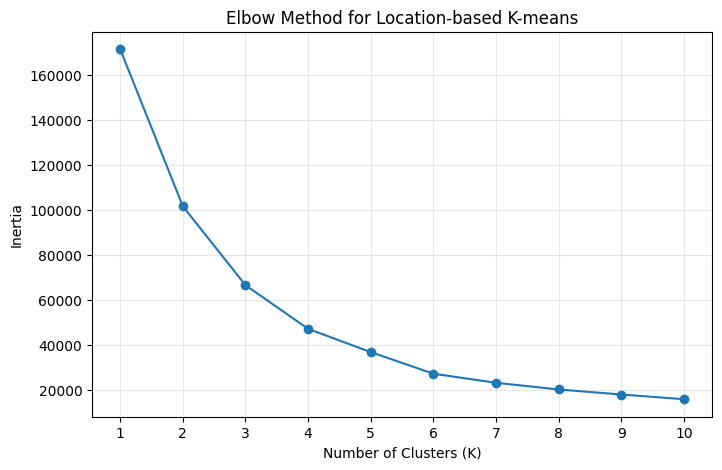

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertias,
    marker="o"
)

plt.title("Elbow Method for Location-based K-means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.grid(alpha=0.3)

plt.show()

### Selecting K

Based on the elbow method, **K = 4** was selected because the inertia decreases rapidly until four clusters and then begins to level off. Increasing the number of clusters beyond four provides only marginal improvement.

In [34]:
# BEGIN AI-assisted code
# Tool: ChatGPT
# Prompt: "Fit a K-means model using K=4."

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

location_df["cluster"] = kmeans.fit_predict(location_scaled)

print(location_df["cluster"].value_counts().sort_index())

# END AI-assisted code

cluster
0    15445
1    45061
2    17204
3     8081
Name: count, dtype: int64


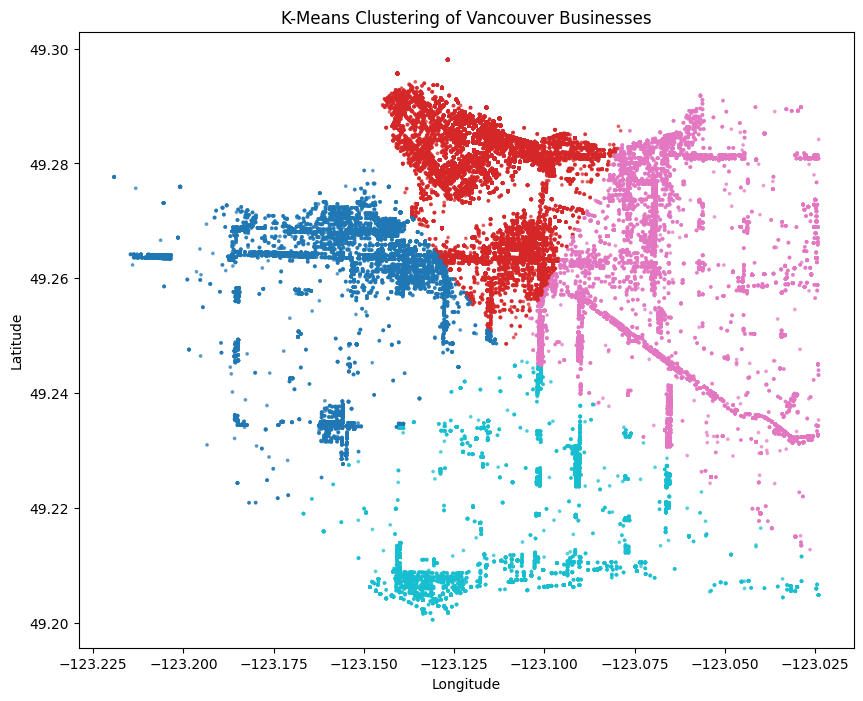

In [35]:
plt.figure(figsize=(10, 8))

plt.scatter(
    location_df["longitude"],
    location_df["latitude"],
    c=location_df["cluster"],
    s=3,
    cmap="tab10",
    alpha=0.6
)

plt.title("K-Means Clustering of Vancouver Businesses")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [36]:
df["location_cluster"] = location_df["cluster"]

## A2.2 DBSCAN Clustering

Unlike K-means, DBSCAN does not require the number of clusters to be specified in advance. Instead, it groups nearby points based on density and identifies isolated observations as noise.

In [37]:
# BEGIN AI-assisted code
# Tool: ChatGPT
# Prompt: "Apply DBSCAN to the standardized latitude and longitude data."

dbscan = DBSCAN(
    eps=0.08,
    min_samples=20
)

location_df["dbscan_cluster"] = dbscan.fit_predict(location_scaled)

print(location_df["dbscan_cluster"].value_counts().sort_index())

# END AI-assisted code

dbscan_cluster
-1      1015
 0     70358
 1       417
 2      4248
 3       949
 4       149
 5       108
 6       209
 7       875
 8        75
 9      1541
 10      291
 11      389
 12      406
 13       93
 14      218
 15      220
 16      170
 17       34
 18      256
 19      114
 20       36
 21      129
 22       70
 23      196
 24       65
 25      186
 26     1201
 27      181
 28      205
 29       95
 30       53
 31       52
 32      115
 33       54
 34       38
 35       48
 36       31
 37       27
 38      146
 39       93
 40      115
 41       54
 42       35
 43       30
 44       35
 45       58
 46       24
 47       23
 48       38
 49       31
 50       20
 51       37
 52       23
 53       47
 54       21
 55       24
 56       20
Name: count, dtype: int64


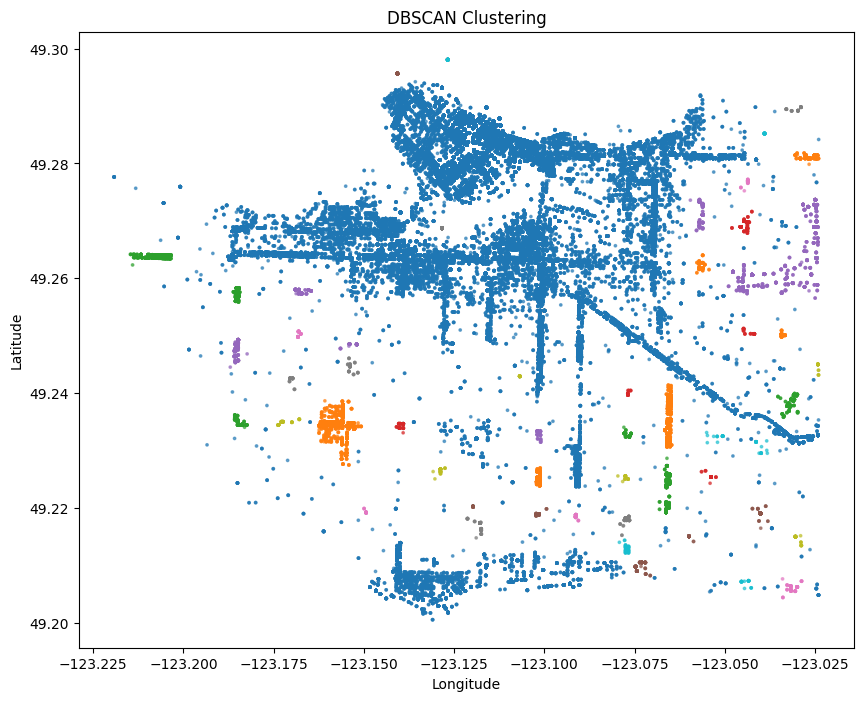

In [38]:
plt.figure(figsize=(10,8))

plt.scatter(
    location_df["longitude"],
    location_df["latitude"],
    c=location_df["dbscan_cluster"],
    s=3,
    cmap="tab10",
    alpha=0.6
)

plt.title("DBSCAN Clustering")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

### Comparison

K-Means partitions every business into one of four clusters and produces compact regions.

DBSCAN identifies clusters based on local density and labels isolated observations as noise. This allows DBSCAN to detect irregularly shaped clusters but makes the result more sensitive to parameter selection.

# A3 — Feature-based Clustering and PCA

In [39]:
feature_df = df[[
    "numberofemployees",
    "feepaid",
    "issue_month",
    "licence_duration",
    "businesstype"
]].copy()

feature_df.head()

,numberofemployees,feepaid,issue_month,licence_duration,businesstype
1,0.0,226.0,11.0,407.0,Long-term Rental
2,0.0,275.0,11.0,407.0,Long-term Rental
3,0.0,188.0,1.0,351.0,Long-term Rental
4,0.0,437.0,2.0,323.0,Long-term Rental
5,0.0,282.0,11.0,400.0,Long-term Rental


In [40]:
feature_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85791 entries, 1 to 204258
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   numberofemployees  85791 non-null  float64
 1   feepaid            85791 non-null  float64
 2   issue_month        85791 non-null  float64
 3   licence_duration   85791 non-null  float64
 4   businesstype       85791 non-null  object 
dtypes: float64(4), object(1)
memory usage: 3.9+ MB


## A3.1 Feature Engineering

The dataset contains both numerical and categorical variables.

Numerical variables were standardized using **StandardScaler**, while the categorical variable (`businesstype`) was transformed using **OneHotEncoder**.

The processed features were then combined for clustering and PCA.

In [41]:
# BEGIN AI-assisted code
# Tool: ChatGPT
# Prompt: "Build a preprocessing pipeline using StandardScaler and OneHotEncoder."

numeric_features = [
    "numberofemployees",
    "feepaid",
    "issue_month",
    "licence_duration"
]

categorical_features = [
    "businesstype"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X = preprocessor.fit_transform(feature_df)

print("Processed feature matrix shape:", X.shape)

# END AI-assisted code

Processed feature matrix shape: (85791, 92)


In [48]:
feature_kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

feature_clusters = feature_kmeans.fit_predict(X)

feature_df["cluster"] = feature_clusters

print(feature_df["cluster"].value_counts().sort_index())

cluster
0    53729
1    23341
2      973
3     7334
4      414
Name: count, dtype: int64


In [49]:
feature_df["cluster"] = feature_clusters

In [50]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X.toarray())

## Selecting K for Feature-based Clustering

The optimal number of clusters was determined using the elbow method based on the processed feature matrix.

In [51]:
feature_inertias = []
feature_k = range(1, 11)

for k in feature_k:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X)

    feature_inertias.append(km.inertia_)

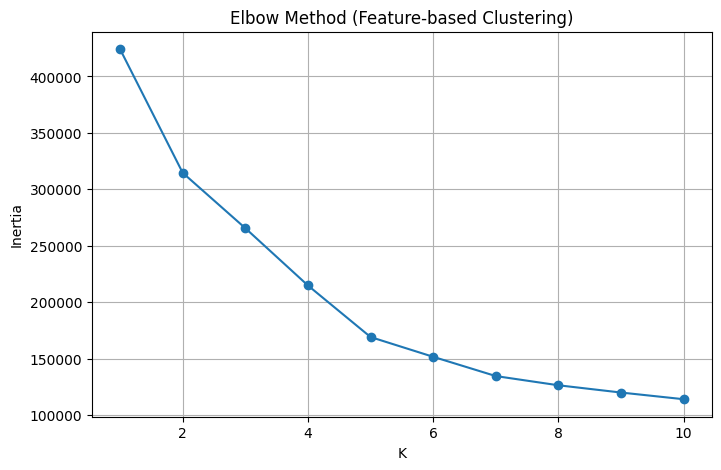

In [52]:
plt.figure(figsize=(8,5))

plt.plot(
    feature_k,
    feature_inertias,
    marker="o"
)

plt.title("Elbow Method (Feature-based Clustering)")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.grid(True)

plt.show()

In [53]:
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X.toarray())

In [54]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)
print("Total explained variance:",
      pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.26601555 0.20830966]
Total explained variance: 0.47432521039548015


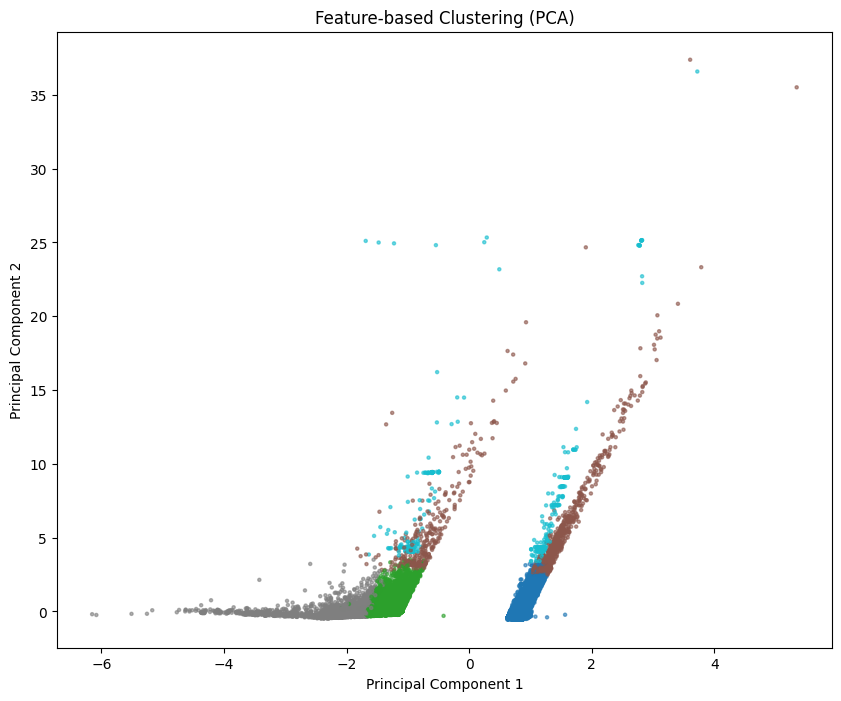

In [55]:
plt.figure(figsize=(10,8))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=feature_df["cluster"],
    cmap="tab10",
    s=5,
    alpha=0.6
)

plt.title("Feature-based Clustering (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

### PCA Interpretation

Principal Component Analysis (PCA) was used to project the processed feature matrix into two dimensions for visualization.

Although some overlap remains between clusters, several groups can be distinguished, indicating that businesses share common characteristics based on licence fee, number of employees, issue month, licence duration, and business type.

In [56]:
cluster_summary = feature_df.groupby("cluster").agg({
    "numberofemployees":"mean",
    "feepaid":"mean",
    "licence_duration":"mean",
    "issue_month":"mean"
})

cluster_summary

,numberofemployees,feepaid,licence_duration,issue_month
cluster,,,,
0,13.425096,444.367935,391.603622,11.529733
1,10.358339,468.205280,324.964269,1.868729
2,34.919836,9592.579034,361.273381,8.786228
3,8.788110,285.453572,122.427325,8.013362
4,1153.246377,374.780193,357.195652,7.386473


# Export Cleaned Data for Part B

The cleaned dataset is exported so that the Streamlit application can load the prepared records without repeating the full cleaning process each time the app runs.

In [57]:
# Select only the columns needed by the Streamlit app

app_columns = [
    "licencenumber",
    "businesstype",
    "localarea",
    "latitude",
    "longitude",
    "numberofemployees",
    "feepaid"
]

app_data = df[app_columns].copy()

# Remove records without a local area
app_data = app_data.dropna(subset=["localarea"])

# Export the cleaned data
app_data.to_csv("clean_business_licences.csv", index=False)

print("Exported rows:", len(app_data))
print("Exported columns:", app_data.columns.tolist())

Exported rows: 85791
Exported columns: ['licencenumber', 'businesstype', 'localarea', 'latitude', 'longitude', 'numberofemployees', 'feepaid']
